<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
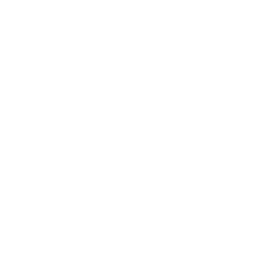
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Clasificación de subtipos moleculares a partir de la expresión génica</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Biotecnología / Oncología genómica &nbsp;|&nbsp; Marzo de 2026</p>
</div>
</div>
</div>

## Resumen ejecutivo

Clasifica muestras de biopsia tumoral en cuatro subtipos moleculares (Luminal-A, Luminal-B, enriquecido en HER2, tipo basal) mediante paneles de biomarcadores de expresión génica. Aplica el análisis discriminante canónico para reducir el espacio de expresión de alta dimensión a ejes de variación interpretables. Utiliza MANOVA para comprobar si los perfiles de expresión medios difieren significativamente entre los subtipos. Valida de forma cruzada para estimar la fiabilidad de la clasificación como apoyo a la decisión clínica en la selección de la vía de tratamiento.

## Fuentes de datos

| Fuente | Descripción | Registros |
|--------|-------------|--------|
| WORK.GENE_EXPR | Expresión génica tumoral con etiquetas de subtipo | 100 |
| WORK.NEW_BIOPSIES | Muestras de biopsia sin clasificar | 100 |


---

In [1]:
/* --------------------------------------------------------
   Genera un conjunto de datos sintético de expresión génica
   con cuatro subtipos moleculares
   -------------------------------------------------------- */
DATOS work.gene_expr;
    LLAMAR streaminit(42);
    LONGITUD mol_subtype $12;
    ARREGLO subtype_list[4] $12 _temporary_ ('LUMINAL_A' 'LUMINAL_B' 'HER2_ENRICH' 'BASAL_LIKE');
    HACER sample_id = 1 HASTA 100;
        tumor_id = cat('TUM-', PUT(sample_id, z5.));
        sub_idx = int(rand('uniform') * 4) + 1;
        mol_subtype = subtype_list[sub_idx];

        /* Marcadores simulados de expresión génica (escala log2) */
        SELECCIONAR (mol_subtype);
            CUANDO ('LUMINAL_A') HACER;
                esr1_expr = round(rand('normal', 11.5, 1.2), 0.01);
                pgr_expr = round(rand('normal', 9.8, 1.5), 0.01);
                erbb2_expr = round(rand('normal', 7.2, 0.9), 0.01);
                ki67_expr = round(rand('normal', 6.0, 1.0), 0.01);
                egfr_expr = round(rand('normal', 6.5, 1.1), 0.01);
                cytokeratin5 = round(rand('normal', 5.0, 0.8), 0.01);
                tp53_mut_load = round(rand('poisson', 1.5), 1);
                prolif_score = round(rand('normal', 3.2, 0.8), 0.01);
            END;
            CUANDO ('LUMINAL_B') HACER;
                esr1_expr = round(rand('normal', 10.0, 1.4), 0.01);
                pgr_expr = round(rand('normal', 7.5, 1.8), 0.01);
                erbb2_expr = round(rand('normal', 8.5, 1.2), 0.01);
                ki67_expr = round(rand('normal', 8.5, 1.2), 0.01);
                egfr_expr = round(rand('normal', 7.0, 1.0), 0.01);
                cytokeratin5 = round(rand('normal', 5.5, 0.9), 0.01);
                tp53_mut_load = round(rand('poisson', 3.0), 1);
                prolif_score = round(rand('normal', 6.0, 1.0), 0.01);
            END;
            CUANDO ('HER2_ENRICH') HACER;
                esr1_expr = round(rand('normal', 6.5, 1.5), 0.01);
                pgr_expr = round(rand('normal', 5.0, 1.2), 0.01);
                erbb2_expr = round(rand('normal', 13.0, 1.0), 0.01);
                ki67_expr = round(rand('normal', 9.0, 1.3), 0.01);
                egfr_expr = round(rand('normal', 8.5, 1.2), 0.01);
                cytokeratin5 = round(rand('normal', 6.0, 1.0), 0.01);
                tp53_mut_load = round(rand('poisson', 5.0), 1);
                prolif_score = round(rand('normal', 7.5, 1.1), 0.01);
            END;
            CUANDO ('BASAL_LIKE') HACER;
                esr1_expr = round(rand('normal', 4.5, 1.3), 0.01);
                pgr_expr = round(rand('normal', 3.8, 1.0), 0.01);
                erbb2_expr = round(rand('normal', 6.0, 1.1), 0.01);
                ki67_expr = round(rand('normal', 10.5, 1.4), 0.01);
                egfr_expr = round(rand('normal', 11.0, 1.3), 0.01);
                cytokeratin5 = round(rand('normal', 10.5, 1.2), 0.01);
                tp53_mut_load = round(rand('poisson', 7.0), 1);
                prolif_score = round(rand('normal', 8.8, 1.2), 0.01);
            END;
            OTRO;
        END;
        SALIDA;
    END;
    ELIMINAR sub_idx;
EJECUTAR;


NOTE: DATA work.gene_expr


NOTE: Wrote work.gene_expr (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Genera muestras de biopsia sin clasificar
   -------------------------------------------------------- */
DATOS work.new_biopsies;
    LLAMAR streaminit(55);
    HACER sample_id = 5001 HASTA 5100;
        tumor_id = cat('TUM-', PUT(sample_id, z5.));
        esr1_expr = round(rand('normal', 8.0, 3.0), 0.01);
        pgr_expr = round(rand('normal', 6.5, 3.0), 0.01);
        erbb2_expr = round(rand('normal', 8.5, 2.5), 0.01);
        ki67_expr = round(rand('normal', 8.0, 2.0), 0.01);
        egfr_expr = round(rand('normal', 8.0, 2.0), 0.01);
        cytokeratin5 = round(rand('normal', 7.0, 2.5), 0.01);
        tp53_mut_load = round(rand('poisson', 4.0), 1);
        prolif_score = round(rand('normal', 6.0, 2.5), 0.01);
        mol_subtype = '';
        SALIDA;
    END;
EJECUTAR;


NOTE: DATA work.new_biopsies


NOTE: Wrote work.new_biopsies (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

                                          Distribución de subtipos moleculares                                          

                                                   The FREQ Procedure

Subtipo molecular    Frequency    Percent
------------------------------------------
BASAL_LIKE                  24     24.00
HER2_ENRICH                 22     22.00
LUMINAL_A                   25     25.00
LUMINAL_B                   29     29.00
                                   Resumen de expresión génica por subtipo molecular                                    

                                                  The MEANS Procedure

                                Analysis Variable : esr1_expr Expresión de ESR1 (log2)

        Subtipo molecular          N Obs           Mean        Std Dev
        --------------------------------------------------------------
        BASAL_LIKE                    24      4.5479167      1.2257100
        HER2_ENRICH                   22      7.1318182      1.4


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mol_subtype.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


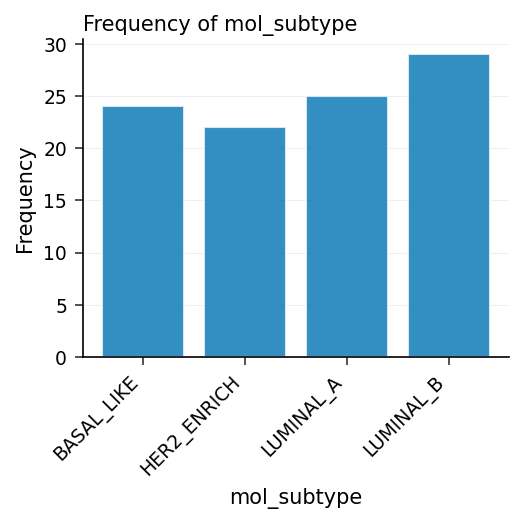

In [3]:
/* --------------------------------------------------------
   Distribución basal de subtipos y perfiles de expresión
   -------------------------------------------------------- */
PROCEDIMIENTO FRECUENCIAS DATOS=work.gene_expr;
    TABLES mol_subtype / nocum;
    ETIQUETA mol_subtype='Subtipo molecular';
    TÍTULO 'Distribución de subtipos moleculares';
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=work.gene_expr n mean std;
    CLASE mol_subtype;
    VAR esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    ETIQUETA mol_subtype='Subtipo molecular'
          esr1_expr='Expresión de ESR1 (log2)'
          pgr_expr='Expresión de PGR (log2)'
          erbb2_expr='Expresión de ERBB2 (log2)'
          ki67_expr='Expresión de Ki-67 (log2)'
          egfr_expr='Expresión de EGFR (log2)'
          cytokeratin5='Citoqueratina 5 (log2)'
          tp53_mut_load='Carga mutacional de TP53'
          prolif_score='Puntuación de proliferación';
    TÍTULO 'Resumen de expresión génica por subtipo molecular';
EJECUTAR;

---

In [4]:
/* --------------------------------------------------------
   Análisis discriminante canónico con MANOVA
   CANONICAL extrae los ejes discriminantes para la visualización.
   MANOVA contrasta la separación global de medias entre subtipos.
   -------------------------------------------------------- */
PROCEDIMIENTO DISCRIM DATOS=work.gene_expr
        METHOD=NORMAL
        pool=TEST
        canonical
        MANOVA
        crossvalidate
        out=work.subtype_canonical
        OUTSTAT=work.subtype_stats;
    CLASE mol_subtype;
    VAR esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    ETIQUETA mol_subtype='Subtipo molecular'
          esr1_expr='Expresión de ESR1 (log2)'
          pgr_expr='Expresión de PGR (log2)'
          erbb2_expr='Expresión de ERBB2 (log2)'
          ki67_expr='Expresión de Ki-67 (log2)'
          egfr_expr='Expresión de EGFR (log2)'
          cytokeratin5='Citoqueratina 5 (log2)'
          tp53_mut_load='Carga mutacional de TP53'
          prolif_score='Puntuación de proliferación';
    TÍTULO 'Análisis discriminante canónico: subtipos moleculares tumorales';
    title2 'Prueba MANOVA de diferencias en los perfiles medios de expresión';
EJECUTAR;

                                   Resumen de expresión génica por subtipo molecular                                    


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Cross-Validation Error Rate: 0.0400
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: Multivariate Statistics:
NOTE:   Wilks' Lambda: 0.0037 (p = 0.000000)
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


---

                                   Resumen de expresión génica por subtipo molecular                                    




NOTE: PROC SGPLOT data=work.subtype_canonical

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


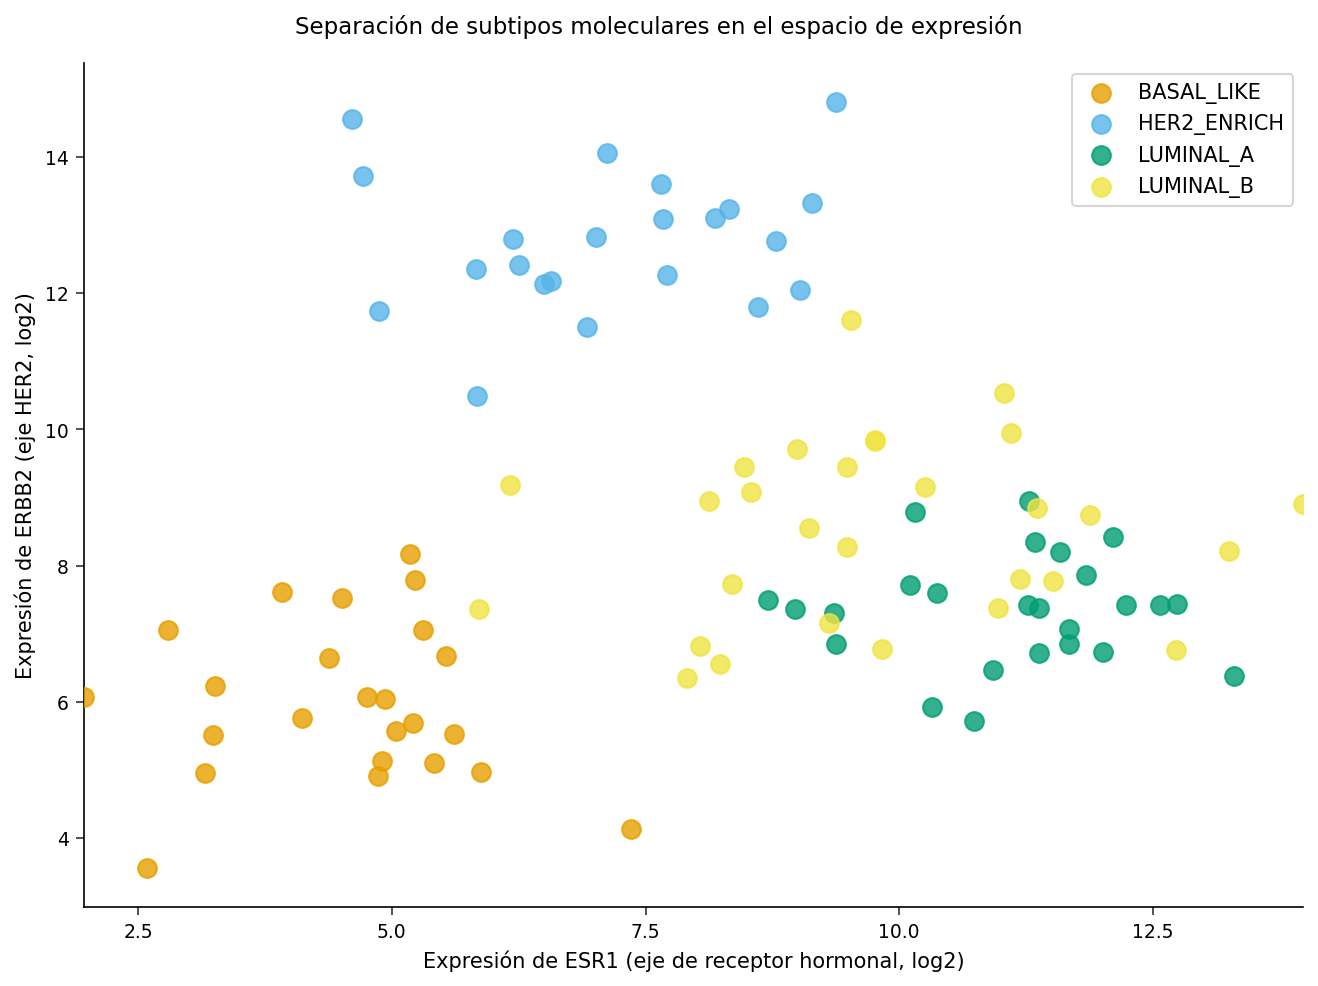

In [5]:
/* --------------------------------------------------------
   Separación de subtipos en el espacio de expresión
   ESR1 (eje de receptor hormonal) frente a ERBB2 (eje HER2),
   tomados del conjunto OUT= del discriminante.
   -------------------------------------------------------- */
PROCEDIMIENTO SGPLOT DATOS=work.subtype_canonical;
    SCATTER x=esr1_expr y=erbb2_expr / GROUP=mol_subtype
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.2;
    XAXIS ETIQUETA='Expresión de ESR1 (eje de receptor hormonal, log2)';
    YAXIS ETIQUETA='Expresión de ERBB2 (eje HER2, log2)';
    TÍTULO 'Separación de subtipos moleculares en el espacio de expresión';
EJECUTAR;

In [6]:
/* --------------------------------------------------------
   Clasifica las muestras de biopsia sin tipificar
   -------------------------------------------------------- */
PROCEDIMIENTO DISCRIM DATOS=work.gene_expr
        testdata=work.new_biopsies
        testout=work.classified_biopsies
        METHOD=NORMAL
        pool=TEST
        canonical;
    CLASE mol_subtype;
    VAR esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    ETIQUETA mol_subtype='Subtipo molecular'
          esr1_expr='Expresión de ESR1 (log2)'
          pgr_expr='Expresión de PGR (log2)'
          erbb2_expr='Expresión de ERBB2 (log2)'
          ki67_expr='Expresión de Ki-67 (log2)'
          egfr_expr='Expresión de EGFR (log2)'
          cytokeratin5='Citoqueratina 5 (log2)'
          tp53_mut_load='Carga mutacional de TP53'
          prolif_score='Puntuación de proliferación';
    TÍTULO 'Clasificación de subtipos moleculares de nuevas biopsias';
EJECUTAR;

                                   Resumen de expresión génica por subtipo molecular                                    


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


                             Distribución prevista de subtipos moleculares: nuevas biopsias                             

                                                   The FREQ Procedure

Subtipo previsto    Frequency    Percent
-----------------------------------------
BASAL_LIKE                  7      7.00
HER2_ENRICH                47     47.00
LUMINAL_A                  10     10.00
LUMINAL_B                  36     36.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq__into_.spec.json
NOTE: PROC FREQ statement used.


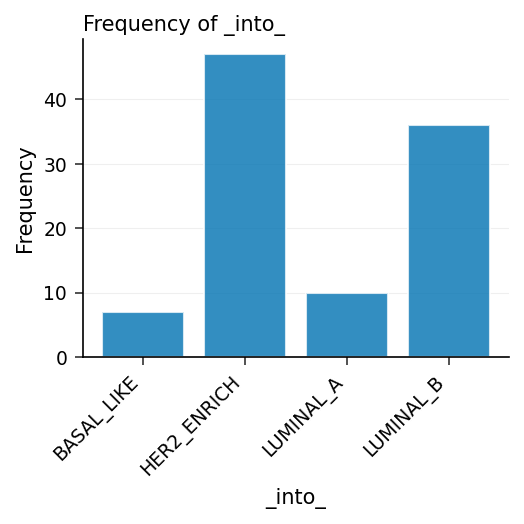

In [7]:
/* --------------------------------------------------------
   Distribución de la clasificación para las nuevas biopsias
   -------------------------------------------------------- */
PROCEDIMIENTO FRECUENCIAS DATOS=work.classified_biopsies;
    TABLES _into_ / nocum;
    ETIQUETA _into_='Subtipo previsto';
    TÍTULO 'Distribución prevista de subtipos moleculares: nuevas biopsias';
EJECUTAR;

---

### Interpretación

La prueba MANOVA confirma una diferencia altamente significativa en los perfiles medios de expresión génica entre los cuatro subtipos moleculares: la Lambda de Wilks = 0.0037 con p < 0.0001, de modo que los subtipos ocupan regiones claramente diferenciadas del espacio de expresión de ocho marcadores. Esa separación es visible en el diagrama de dispersión del espacio de expresión, donde los tumores luminales se sitúan en la parte alta del eje ESR1 (receptor hormonal), mientras que los tumores enriquecidos en HER2 se desplazan hacia lo alto del eje ERBB2 y los tumores de tipo basal caen hacia la esquina inferior izquierda de ambos ejes. La clasificación por resustitución de los 100 tumores etiquetados es perfecta (0 % de error aparente), y la validación cruzada dejando uno fuera sitúa la tasa de error en apenas un 4 %: una exactitud validada de forma cruzada honesta del 96 %, con cada subtipo recuperado correctamente en la matriz de confusión validada. Al aplicar el clasificador entrenado a las 100 biopsias sin etiquetar, se asignan 47 a enriquecido en HER2, 36 a Luminal-B, 10 a Luminal-A y 7 a tipo basal; la inclinación hacia enriquecido en HER2 refleja las lecturas elevadas de ERBB2 y de proliferación del panel de biopsias. Estas asignaciones de subtipo guían la selección de la vía de tratamiento: terapia endocrina para los tumores luminales, agentes dirigidos anti-HER2 para el grupo enriquecido en HER2 y regímenes de quimioterapia para los tumores de tipo basal.

---

In [8]:
/* --------------------------------------------------------
   Exporta las biopsias clasificadas para la planificación del tratamiento
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.classified_biopsies
    OUTFILE='classified_biopsy_subtypes.csv'
    DBMS=csv REPLACE;
EJECUTAR;

PROCEDIMIENTO EXPORT DATOS=work.subtype_canonical
    OUTFILE='canonical_subtype_scores.csv'
    DBMS=csv REPLACE;
EJECUTAR;


NOTE: PROC EXPORT data=work.classified_biopsies outfile=classified_biopsy_subtypes.csv

NOTE: Exported 100 rows to classified_biopsy_subtypes.csv.
NOTE: PROC EXPORT data=work.subtype_canonical outfile=canonical_subtype_scores.csv

NOTE: Exported 100 rows to canonical_subtype_scores.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desarrollado con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>